## Setup 

In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path('..').resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

INTERIM = Path('../data/interim')
PROCESSED = Path('../data/processed')
# Go up two levels from property/notebooks/ to reach root, then into reports/property/
FIGS_DIR = Path('../../reports/property/figures')
TABLES_DIR = Path('../../reports/property/tables')

FIGS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore')

# Try to import geopandas for mapping
try:
    import geopandas as gpd
    HAVE_GPD = True
except ImportError:
    HAVE_GPD = False
    print("GeoPandas not available. Figure 5.1 will be skipped.")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 150


## Figure 5.1: Choropleth Map of Local Authorities


Saved: ../../reports/property/figures/fig_5_1_la_choropleth.png


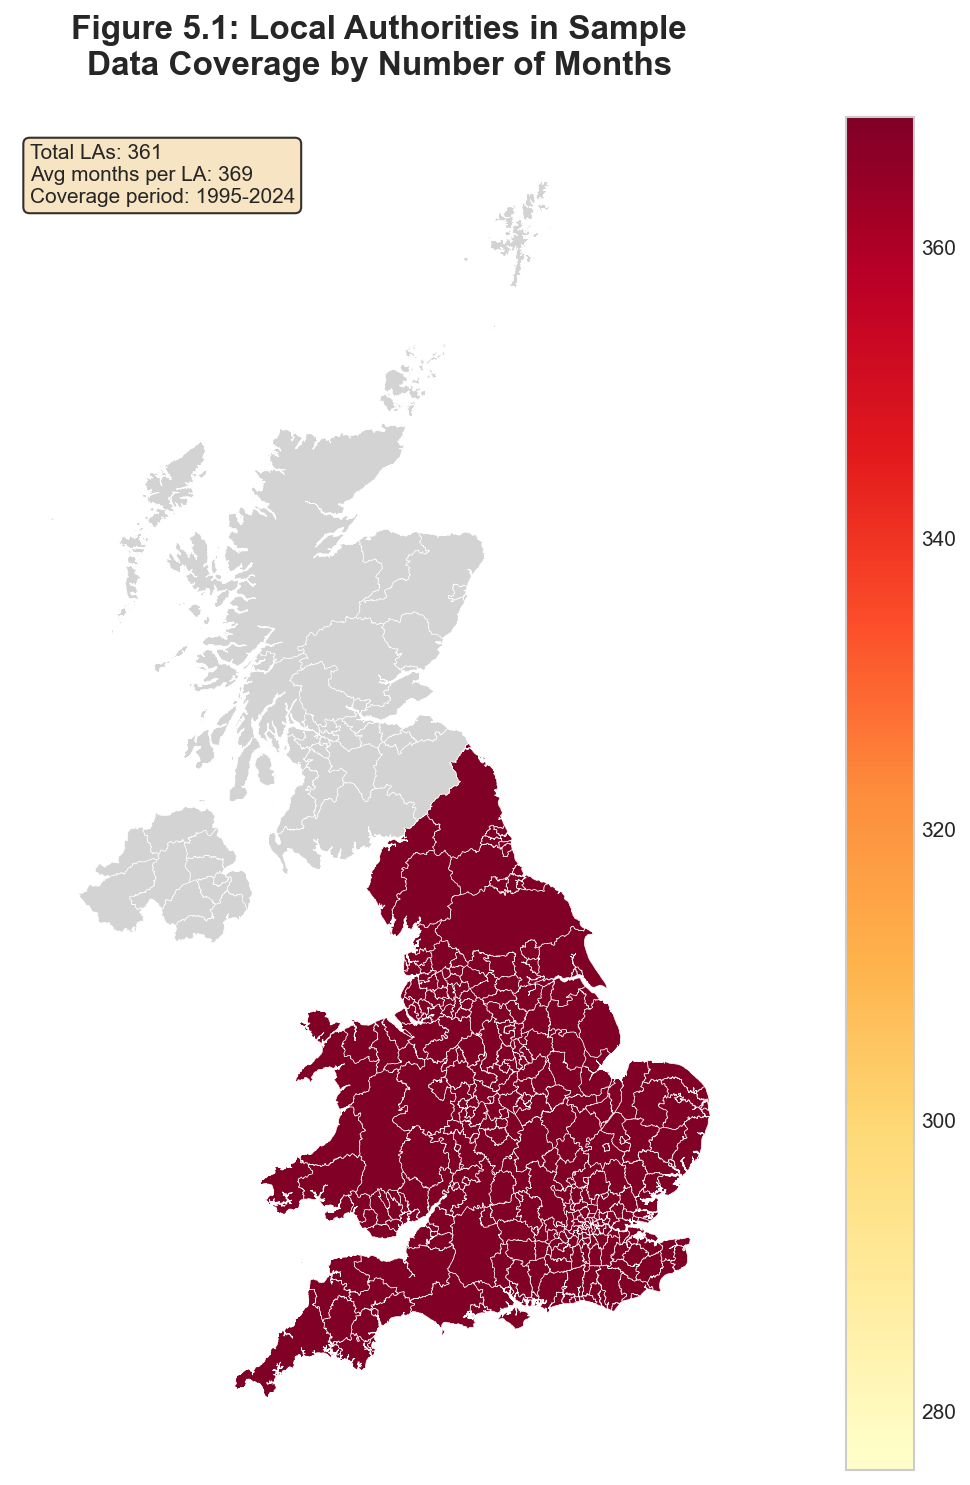

In [5]:
if HAVE_GPD:
    # Load LA boundaries
    boundaries_path = INTERIM / 'la_boundaries.parquet'
    if boundaries_path.exists():
        boundaries = gpd.read_parquet(boundaries_path)

        # Load LA data to get coverage info
        prices_path = INTERIM / 'la_month_prices.parquet'
        if prices_path.exists():
            prices = pd.read_parquet(prices_path)

            # Calculate coverage: first and last month per LA
            coverage = prices.groupby('LA_code').agg({
                'month': ['min', 'max', 'count']
            }).reset_index()
            coverage.columns = ['LA_code', 'first_month', 'last_month', 'n_months']

            # Merge with boundaries
            boundaries = boundaries.merge(coverage, on='LA_code', how='left')

            # Create figure
            fig, ax = plt.subplots(figsize=(14, 10))

            # Plot boundaries colored by number of months of data
            boundaries.plot(
                column='n_months',
                ax=ax,
                legend=True,
                cmap='YlOrRd',
                edgecolor='white',
                linewidth=0.3,
                missing_kwds={'color': 'lightgray', 'label': 'No data'}
            )

            ax.set_title('Figure 5.1: Local Authorities in Sample\n' +
                        'Data Coverage by Number of Months',
                        fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel('Longitude', fontsize=12)
            ax.set_ylabel('Latitude', fontsize=12)
            ax.axis('off')

            # Add text box with summary stats
            n_las = boundaries['LA_code'].nunique()
            total_months = boundaries['n_months'].sum()
            avg_months = boundaries['n_months'].mean()

            textstr = f'Total LAs: {n_las}\n'
            textstr += f'Avg months per LA: {avg_months:.0f}\n'
            textstr += f'Coverage period: 1995-2024'

            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
                    verticalalignment='top', bbox=props)

            plt.tight_layout()

            # Save figure
            fig_path = FIGS_DIR / 'fig_5_1_la_choropleth.png'
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            print(f"Saved: {fig_path}")
            plt.show()
        else:
            print(f"{prices_path} not found. Skipping Figure 5.1.")
    else:
        print(f"{boundaries_path} not found. Skipping Figure 5.1.")
else:
    print("GeoPandas not available. Skipping Figure 5.1.")


## Figure 5.2: Example Time Series - Raw Median Prices vs Hedonic Index


Selected preferred LA: Westminster (from preferred list)
Saved: ../../reports/property/figures/fig_5_2_hedonic_comparison.png
Selected LA: Westminster (E09000033)
Coverage: 1995-01 to 2025-09
Number of months: 369


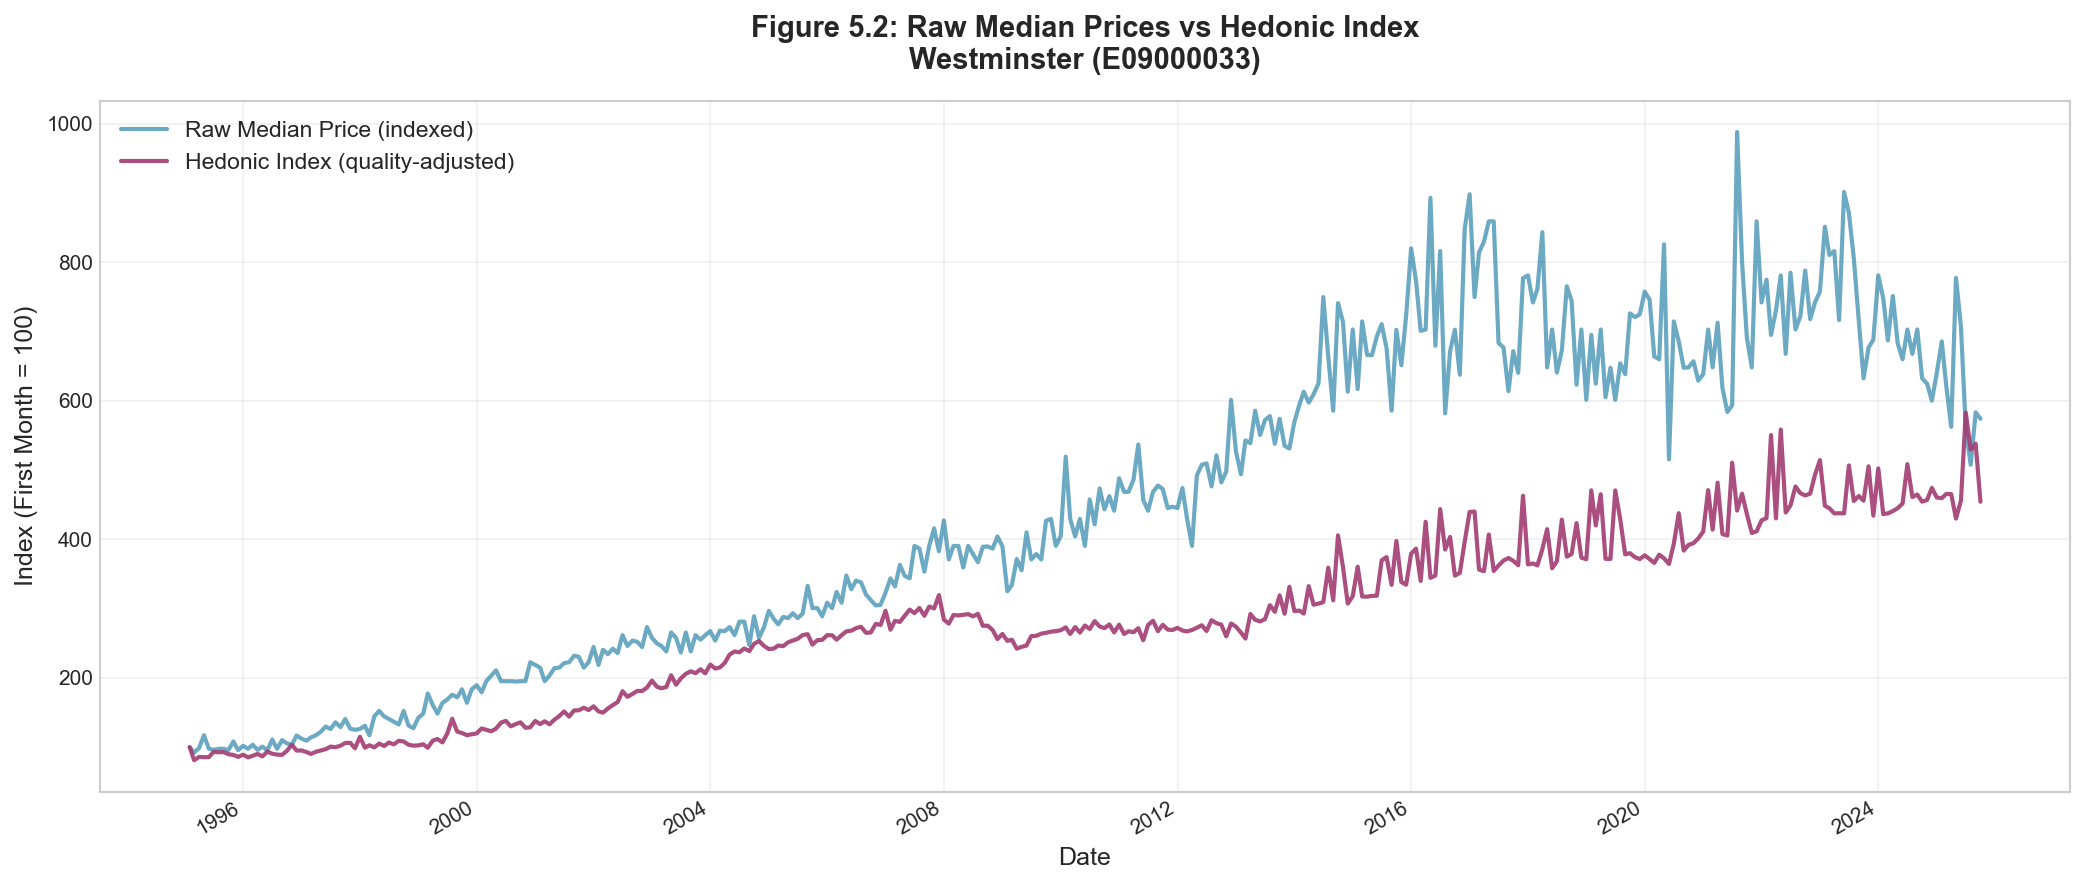

In [8]:
# Load data
prices_path = INTERIM / 'la_month_prices.parquet'
hedonic_path = INTERIM / 'la_month_hedonic.parquet'

if prices_path.exists() and hedonic_path.exists():
    prices = pd.read_parquet(prices_path)
    hedonic = pd.read_parquet(hedonic_path)

    # Merge
    combined = prices.merge(
        hedonic[['LA_code', 'month', 'hedonic_ix']],
        on=['LA_code', 'month'],
        how='inner'
    )

    # Select a representative LA with good coverage
    # Choose one with long history and good data quality
    la_coverage = combined.groupby('LA_code').agg({
        'month': ['min', 'max', 'count'],
        'median_price': 'mean'
    }).reset_index()
    la_coverage.columns = ['LA_code', 'first_month', 'last_month', 'n_months', 'avg_price']

    # Merge with LA names
    la_coverage = la_coverage.merge(
        prices[['LA_code', 'LA_name']].drop_duplicates(),
        on='LA_code',
        how='left'
    )

    # Select a well-known, representative LA with good coverage
    # Prioritize London boroughs (most recognizable and well-covered)
    # Then major cities, then other well-known towns
    preferred_las = [
        # London boroughs (highest priority)
        'Westminster', 'Camden', 'Kensington and Chelsea', 'Islington',
        'Hammersmith and Fulham', 'Wandsworth', 'Greenwich',
        # Major cities
        'Birmingham', 'Manchester', 'Leeds', 'Liverpool', 'Sheffield',
        'Bristol', 'Leicester', 'Coventry', 'Nottingham',
        # Other well-known towns
        'Oxford', 'Cambridge', 'Warwick', 'Stratford-on-Avon'
    ]

    # Filter to LAs with good coverage (top quartile by months)
    min_months = la_coverage['n_months'].quantile(0.75)
    well_covered = la_coverage[la_coverage['n_months'] >= min_months].copy()

    # Try to find a preferred LA first (London boroughs prioritized)
    selected_la = None
    for pref_name in preferred_las:
        match = well_covered[well_covered['LA_name'].str.contains(pref_name, case=False, na=False, regex=False)]
        if not match.empty:
            selected_la = match.iloc[0]
            print(f"Selected preferred LA: {selected_la['LA_name']} (from preferred list)")
            break

    # If no preferred LA found, pick one with good coverage and reasonable price level
    if selected_la is None:
        # Select from top coverage, avoiding extremes
        well_covered = well_covered.sort_values('n_months', ascending=False)
        # Pick one from the middle of well-covered LAs (not the very top, not the bottom)
        idx = len(well_covered) // 3  # Pick from upper third
        selected_la = well_covered.iloc[idx]
        print(f"Selected representative LA: {selected_la['LA_name']} (well-covered, not from preferred list)")

    selected_la_code = selected_la['LA_code']
    selected_la_name = selected_la['LA_name']

    # Filter to selected LA
    la_data = combined[combined['LA_code'] == selected_la_code].copy()
    la_data = la_data.sort_values('month')

    # Normalize median price to start at 100 for comparison
    first_price = la_data['median_price'].iloc[0]
    la_data['median_price_indexed'] = (la_data['median_price'] / first_price) * 100

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot both series
    ax.plot(la_data['month'], la_data['median_price_indexed'],
            label='Raw Median Price (indexed)', linewidth=2, alpha=0.7, color='#2E86AB')
    ax.plot(la_data['month'], la_data['hedonic_ix'],
            label='Hedonic Index (quality-adjusted)', linewidth=2, alpha=0.9, color='#A23B72')

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Index (First Month = 100)', fontsize=12)
    ax.set_title(f'Figure 5.2: Raw Median Prices vs Hedonic Index\n' +
                f'{selected_la_name} ({selected_la_code})',
                fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)

    # Format x-axis dates
    fig.autofmt_xdate()

    plt.tight_layout()

    # Save figure
    fig_path = FIGS_DIR / 'fig_5_2_hedonic_comparison.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {fig_path}")
    print(f"Selected LA: {selected_la_name} ({selected_la_code})")
    print(f"Coverage: {la_data['month'].min().strftime('%Y-%m')} to {la_data['month'].max().strftime('%Y-%m')}")
    print(f"Number of months: {len(la_data)}")
    plt.show()
else:
    print(f" Required data files not found. Skipping Figure 5.2.")


## Table 5.1: Summary of Feature Families


In [11]:
# Load feature data to get actual feature names
features_path = INTERIM / 'la_month_features_enriched_PROP_v1__CORE.parquet'

if features_path.exists():
    # Load just the first row to get column names (parquet doesn't support nrows)
    features = pd.read_parquet(features_path).head(1)

    # Define feature family mapper (same as in Notebook 7P)
    def feature_family(name: str) -> str:
        """Map feature name to family (property-specific)."""
        n = name.lower()
        # Price dynamics (momentum, volatility, returns, liquidity)
        if n.startswith(('mom_', 'ret_', 'vol_', 'drawdown', 'liquidity', 'sharpe')):
            return 'Price Dynamics'
        # Static context (amenities, transport, deprivation, broadband)
        if n.startswith(('fastfood', 'supermkt', 'stops_', 'imd_', 'airbnb', 'gigabit')):
            return 'Static Context'
        # Time-varying context (rent indices, HPI, national trends)
        if n.startswith(('iphrp', 'hpi_')) or ('_yoy' in n and 'rent' not in n):
            return 'Time-Varying Context'
        # Rent features (WITHRENT only: rent growth, price-to-rent, rent gaps)
        if 'rent' in n and ('yoy' in n or 'gap' in n or 'ptr' in n or 'price_to_rent' in n):
            return 'Rent/Valuation Features'
        # Regime flags
        if n.startswith(('bear_', 'high_', 'oil_', 'strong_', 'vol_regime')):
            return 'Regime Flags'
        return 'Other'

    # Exclude ID and target columns
    exclude_cols = ['LA_code', 'LA_name', 'month', 'fold', 'split',
                    'y_ret_1m_fwd', 'y_ret_3m_fwd', 'y_up_1m', 'y_up_3m']
    feature_cols = [c for c in features.columns if c not in exclude_cols]

    # Categorize features
    feature_families = {}
    for feat in feature_cols:
        family = feature_family(feat)
        if family not in feature_families:
            feature_families[family] = []
        feature_families[family].append(feat)

    # Create summary table
    summary_data = []
    for family, feats in sorted(feature_families.items()):
        summary_data.append({
            'Feature Family': family,
            'Count': len(feats),
            'Example Variables': ', '.join(feats[:5]) + ('...' if len(feats) > 5 else '')
        })

    summary_df = pd.DataFrame(summary_data)

    # Display table
    print("Table 5.1: Summary of Feature Families for Property Pipeline\n")
    print(summary_df.to_string(index=False))

    # Save to CSV and LaTeX
    csv_path = TABLES_DIR / 'table_5_1_feature_families.csv'
    summary_df.to_csv(csv_path, index=False)
    print(f"\nSaved CSV: {csv_path}")

    # Also save detailed feature list by family
    detailed_data = []
    for family, feats in sorted(feature_families.items()):
        for feat in sorted(feats):
            detailed_data.append({
                'Feature Family': family,
                'Feature Name': feat
            })

    detailed_df = pd.DataFrame(detailed_data)
    detailed_path = TABLES_DIR / 'table_5_1_feature_families_detailed.csv'
    detailed_df.to_csv(detailed_path, index=False)
    print(f"Saved detailed list: {detailed_path}")

    # Print total count
    print(f"\nTotal features: {len(feature_cols)}")

else:
    print(f" {features_path} not found. Skipping Table 5.1.")


Table 5.1: Summary of Feature Families for Property Pipeline

         Feature Family  Count                                                                       Example Variables
                  Other      9                                  px_used, n_sales, n_sales_3m, thin_flag, rent_index...
         Price Dynamics      7                                               ret_1m, ret_3m, ret_6m, mom_3m, mom_6m...
Rent/Valuation Features      2                                                                 price_to_rent, rent_gap
         Static Context     13 gigabit_pct, fastfood_per_1k_hh, supermkt_per_1k_hh, stops_per_km2, stops_per_10k_hh...
   Time-Varying Context      4                                  iphrp_england, iphrp_yoy, iphrp_england_z, iphrp_yoy_z

Saved CSV: ../../reports/property/tables/table_5_1_feature_families.csv
Saved detailed list: ../../reports/property/tables/table_5_1_feature_families_detailed.csv

Total features: 35


## Figure 5.3: Cross-Validation Scheme Diagram (Conceptual)


Saved: ../../reports/property/figures/fig_5_3_cv_scheme.png


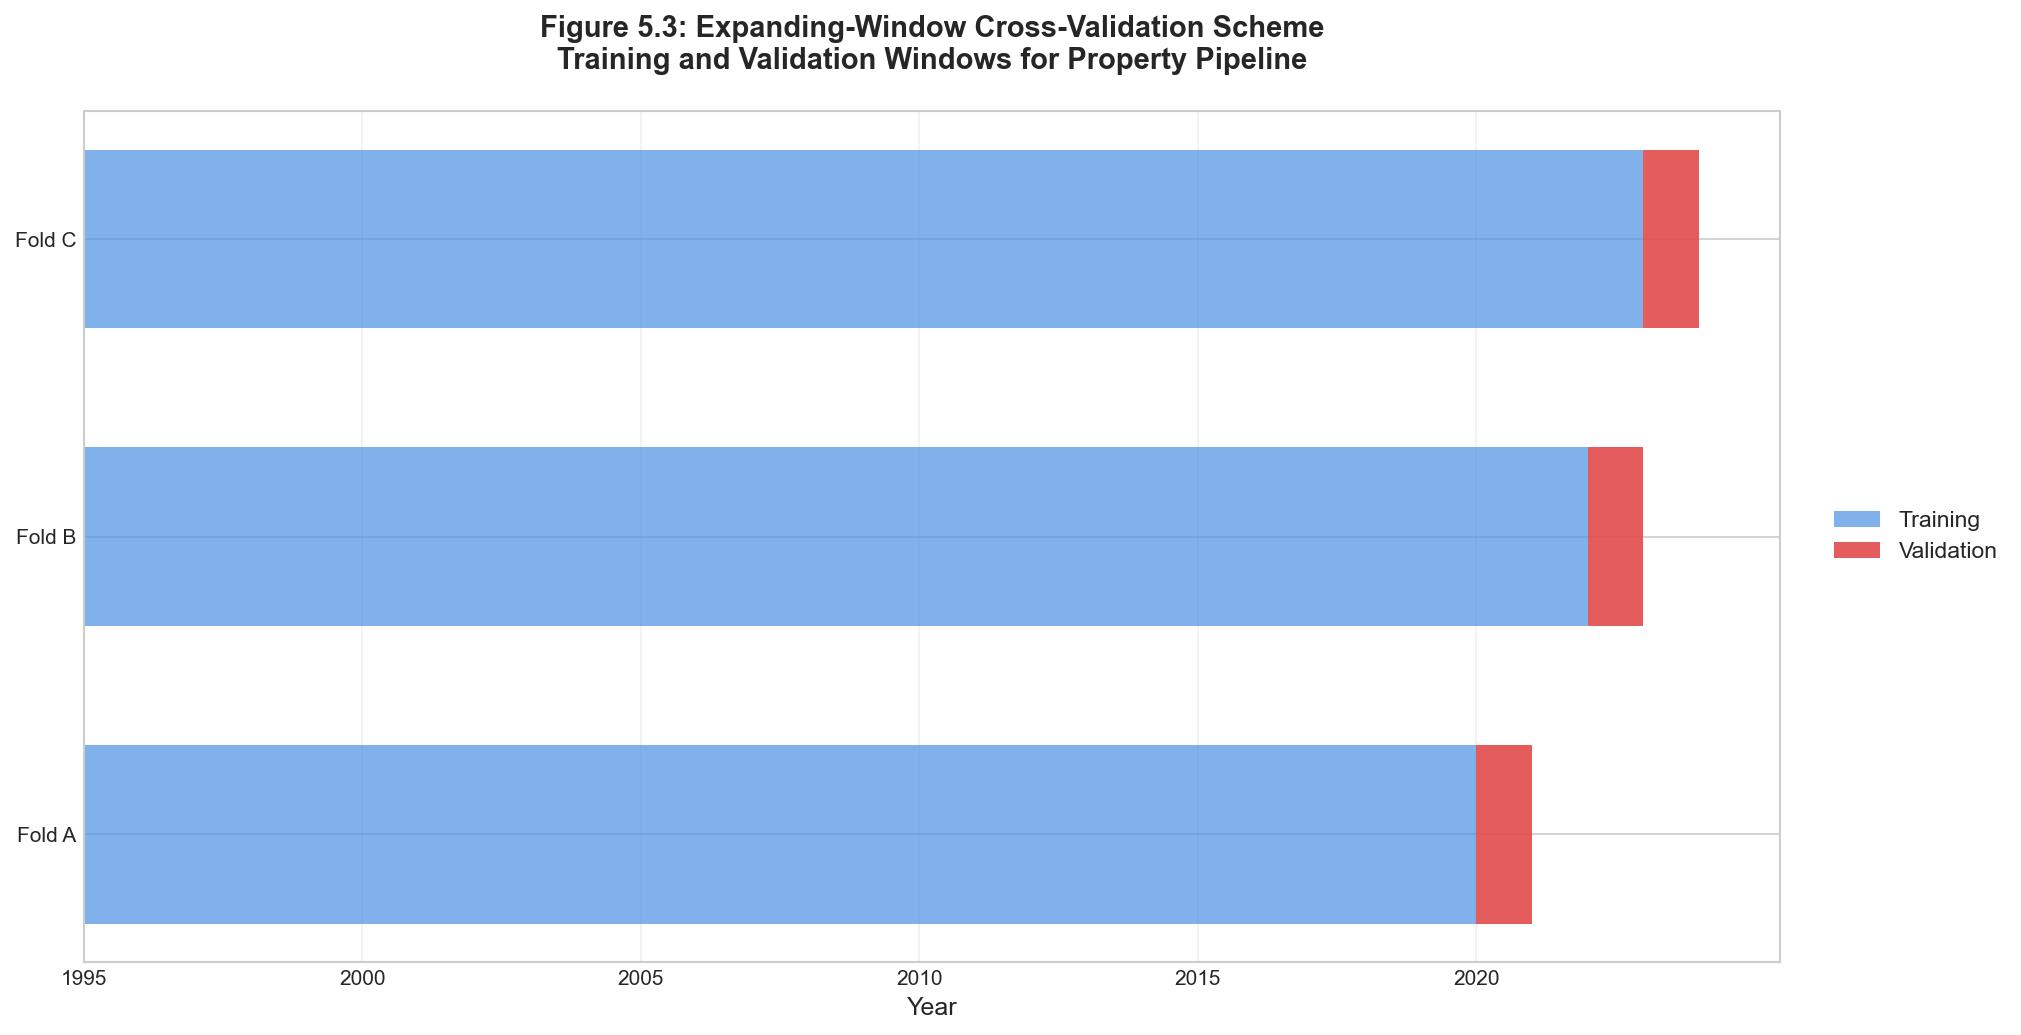

In [14]:
# Create a simple conceptual diagram of the CV scheme
fig, ax = plt.subplots(figsize=(16, 7))

# Define time periods
years = np.arange(1995, 2025)
x_pos = np.arange(len(years))

# Define folds
folds = {
    'Fold A': {'train': (1995, 2019), 'val': (2020, 2020)},
    'Fold B': {'train': (1995, 2021), 'val': (2022, 2022)},
    'Fold C': {'train': (1995, 2022), 'val': (2023, 2023)}
}

# Colors
train_color = '#4A90E2'
val_color = '#E24A4A'

# Plot each fold
y_offset = 0
fold_labels = []

for fold_name, periods in folds.items():
    train_start, train_end = periods['train']
    val_start, val_end = periods['val']

    # Training period
    train_start_idx = train_start - 1995
    train_end_idx = train_end - 1995 + 1
    ax.barh(y_offset, train_end_idx - train_start_idx,
            left=train_start_idx, height=0.6,
            color=train_color, alpha=0.7, label='Training' if y_offset == 0 else '')

    # Validation period
    val_start_idx = val_start - 1995
    val_end_idx = val_end - 1995 + 1
    ax.barh(y_offset, val_end_idx - val_start_idx,
            left=val_start_idx, height=0.6,
            color=val_color, alpha=0.9, label='Validation' if y_offset == 0 else '')

    fold_labels.append(fold_name)
    y_offset += 1

# Formatting
ax.set_yticks(range(len(folds)))
ax.set_yticklabels(fold_labels)
ax.set_xticks(range(0, len(years), 5))
ax.set_xticklabels(years[::5])
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Figure 5.3: Expanding-Window Cross-Validation Scheme\n' +
            'Training and Validation Windows for Property Pipeline',
            fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

# Place legend outside the plot area (to the right)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11, framealpha=0.9)

# Adjust layout to prevent legend overflow - leave extra space on the right
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save figure
fig_path = FIGS_DIR / 'fig_5_3_cv_scheme.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
plt.show()


Saved: ../../reports/property/figures/fig_6_1_auc_by_fold_cls_y_up_3m.png


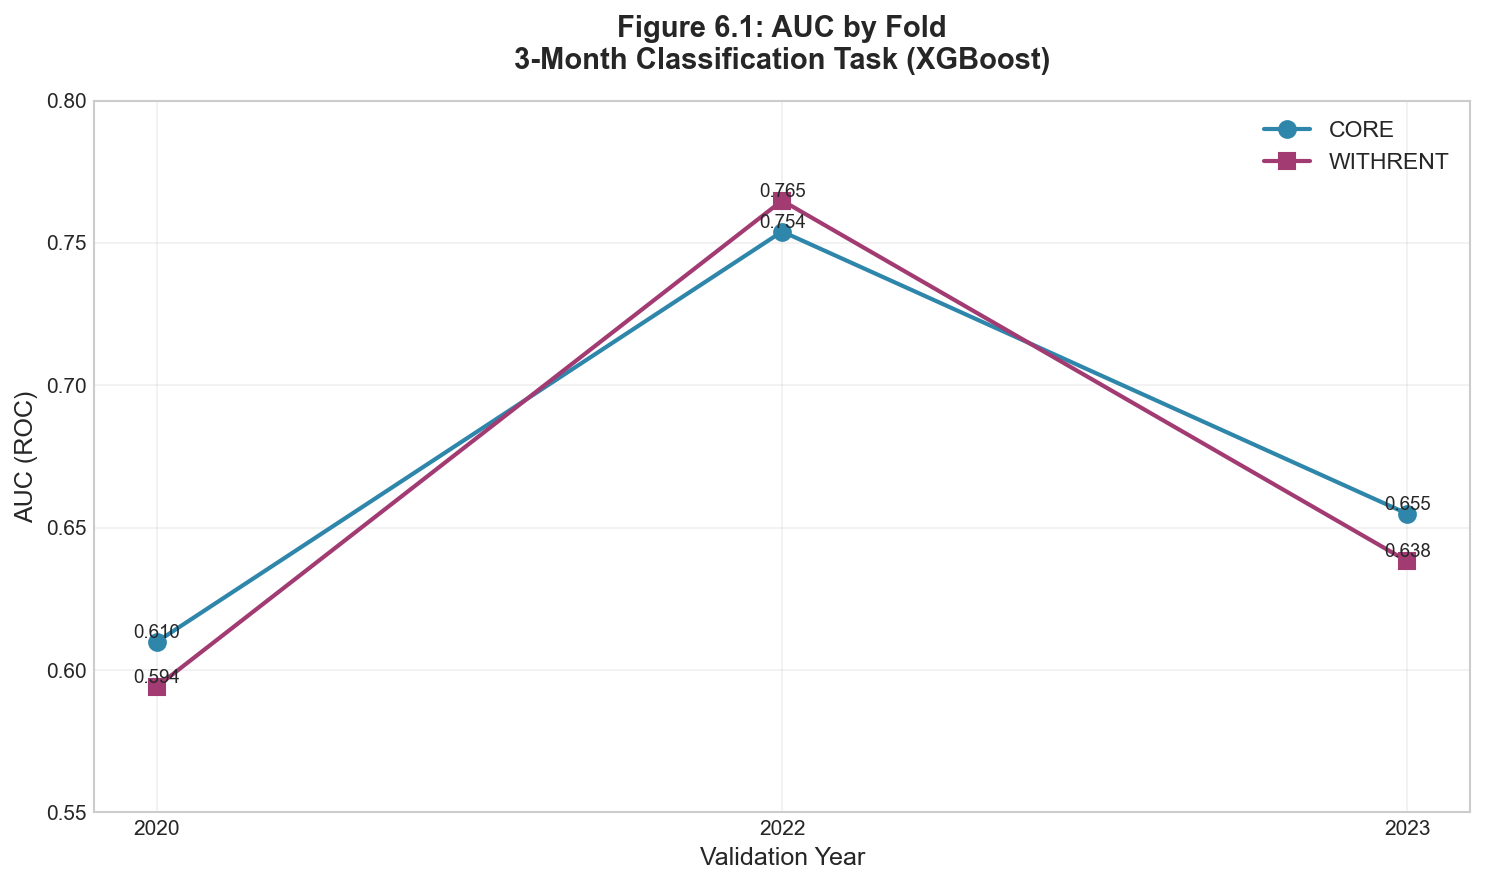


Summary:
variant      CORE  WITHRENT
year                       
2020     0.609904  0.594172
2022     0.754036  0.764902
2023     0.654866  0.638195


In [16]:
# Load metrics
metrics_path = TABLES_DIR / 'metrics_PROP_v1_property.parquet'

if metrics_path.exists():
    metrics = pd.read_parquet(metrics_path)

    # Filter to 3-month classification, XGBoost 
    cls_3m = metrics[
        (metrics['target'] == 'y_up_3m') &
        (metrics['task'] == 'cls') &
        (metrics['model'] == 'xgb')
    ].copy()

    if not cls_3m.empty:
        # Map fold names to years for x-axis
        fold_to_year = {
            'A_val2020': '2020',
            'B_val2022': '2022',
            'C_val2023': '2023'
        }
        cls_3m['year'] = cls_3m['fold'].map(fold_to_year)

        # Pivot for plotting
        pivot_data = cls_3m.pivot_table(
            index='year',
            columns='variant',
            values='auc',
            aggfunc='mean'
        )

        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot lines for each variant
        ax.plot(pivot_data.index, pivot_data['CORE'],
                marker='o', linewidth=2, markersize=8, label='CORE', color='#2E86AB')
        ax.plot(pivot_data.index, pivot_data['WITHRENT'],
                marker='s', linewidth=2, markersize=8, label='WITHRENT', color='#A23B72')

        ax.set_xlabel('Validation Year', fontsize=12)
        ax.set_ylabel('AUC (ROC)', fontsize=12)
        ax.set_title('Figure 6.1: AUC by Fold\n' +
                    '3-Month Classification Task (XGBoost)',
                    fontsize=14, fontweight='bold', pad=15)
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.55, 0.80])

        # Add value labels on points
        for variant in ['CORE', 'WITHRENT']:
            for year in pivot_data.index:
                val = pivot_data.loc[year, variant]
                ax.text(year, val, f'{val:.3f}',
                       ha='center', va='bottom', fontsize=9)

        plt.tight_layout()

        # Save figure
        fig_path = FIGS_DIR / 'fig_6_1_auc_by_fold_cls_y_up_3m.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_path}")
        plt.show()

        # Print summary
        print("\nSummary:")
        print(pivot_data.to_string())
    else:
        print("No data found for 3-month classification XGBoost models.")
else:
    print(f"{metrics_path} not found. Skipping Figure 6.1.")


## Figure 6.2: Rank IC by Fold (Linear vs XGBoost, 3-month Regression)


Saved: ../../reports/property/figures/fig_6_2_rankic_by_fold_reg_y_ret_3m_fwd.png


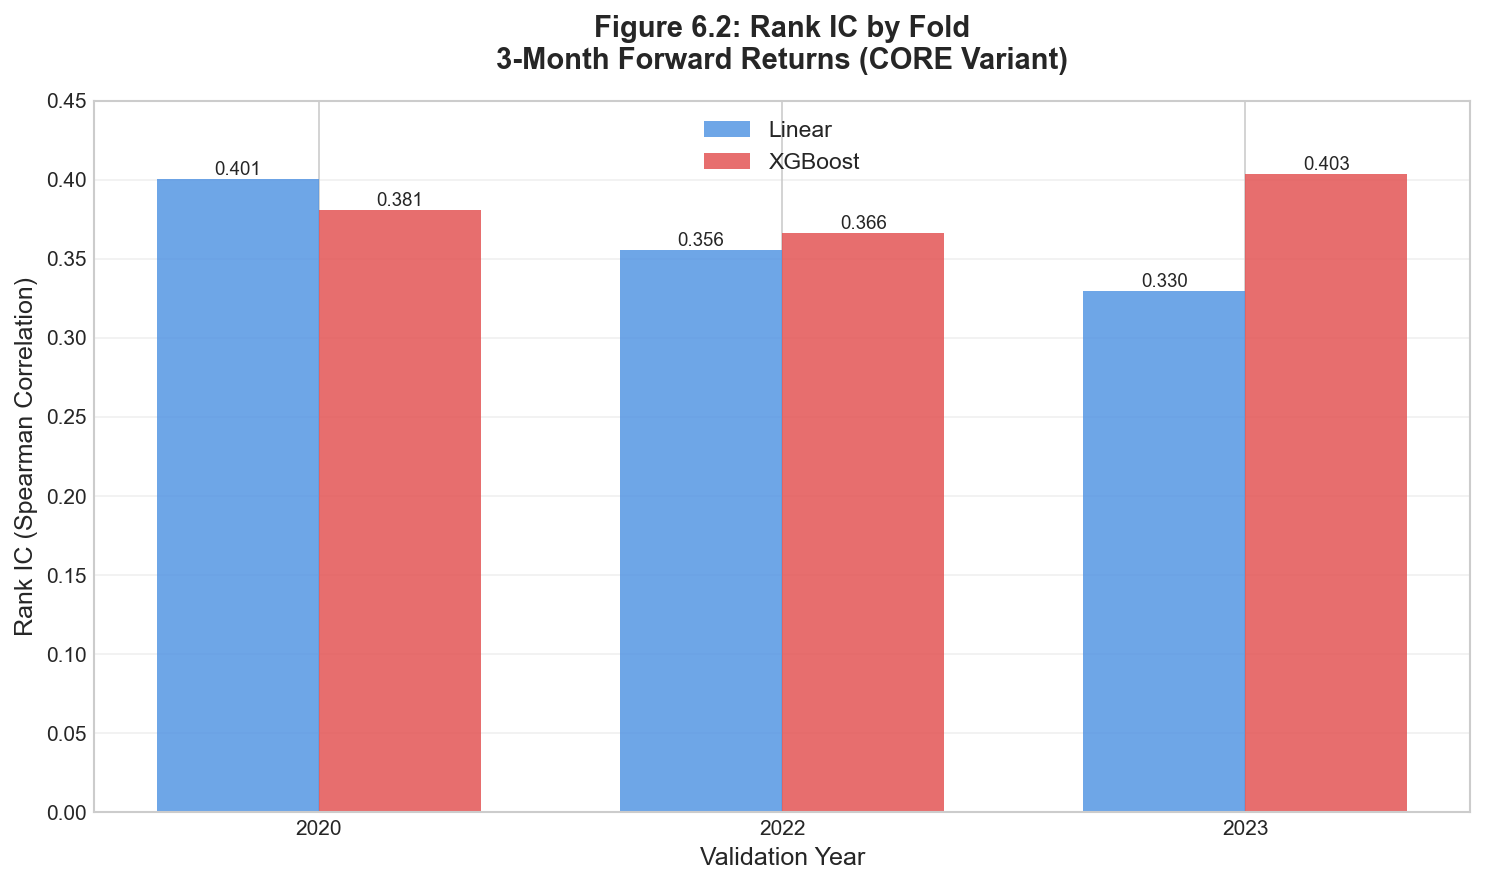


Summary:
model_name    Linear   XGBoost
year                          
2020        0.400509  0.380981
2022        0.355690  0.366500
2023        0.329753  0.403376


In [19]:
# Load metrics
metrics_path = TABLES_DIR / 'metrics_PROP_v1_property.parquet'

if metrics_path.exists():
    metrics = pd.read_parquet(metrics_path)

    # Filter to 3-month regression
    reg_3m = metrics[
        (metrics['target'] == 'y_ret_3m_fwd') &
        (metrics['task'] == 'reg')
    ].copy()

    if not reg_3m.empty:
        # Map fold names to years and model names
        fold_to_year = {
            'A_val2020': '2020',
            'B_val2022': '2022',
            'C_val2023': '2023'
        }
        model_to_name = {
            'logit': 'Linear',
            'xgb': 'XGBoost'
        }

        reg_3m['year'] = reg_3m['fold'].map(fold_to_year)
        reg_3m['model_name'] = reg_3m['model'].map(model_to_name)

        # Average across variants for this figure 
        # CORE variant for consistency
        reg_3m_core = reg_3m[reg_3m['variant'] == 'CORE'].copy()

        # Pivot for plotting
        pivot_data = reg_3m_core.pivot_table(
            index='year',
            columns='model_name',
            values='rank_ic',
            aggfunc='mean'
        )

        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))

        # Bar chart
        x = np.arange(len(pivot_data.index))
        width = 0.35

        bars1 = ax.bar(x - width/2, pivot_data['Linear'], width,
                      label='Linear', color='#4A90E2', alpha=0.8)
        bars2 = ax.bar(x + width/2, pivot_data['XGBoost'], width,
                      label='XGBoost', color='#E24A4A', alpha=0.8)

        ax.set_xlabel('Validation Year', fontsize=12)
        ax.set_ylabel('Rank IC (Spearman Correlation)', fontsize=12)
        ax.set_title('Figure 6.2: Rank IC by Fold\n' +
                    '3-Month Forward Returns (CORE Variant)',
                    fontsize=14, fontweight='bold', pad=15)
        ax.set_xticks(x)
        ax.set_xticklabels(pivot_data.index)
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 0.45])

        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=9)

        plt.tight_layout()

        # Save figure
        fig_path = FIGS_DIR / 'fig_6_2_rankic_by_fold_reg_y_ret_3m_fwd.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_path}")
        plt.show()

        # Print summary
        print("\nSummary:")
        print(pivot_data.to_string())
    else:
        print("No data found for 3-month regression models.")
else:
    print(f"{metrics_path} not found. Skipping Figure 6.2.")


## Figure 6.5: Contextual Features SHAP Comparison (CORE vs WITHRENT)


Saved: ../../reports/property/figures/fig_6_5_contextual_shap_core_vs_withrent.png


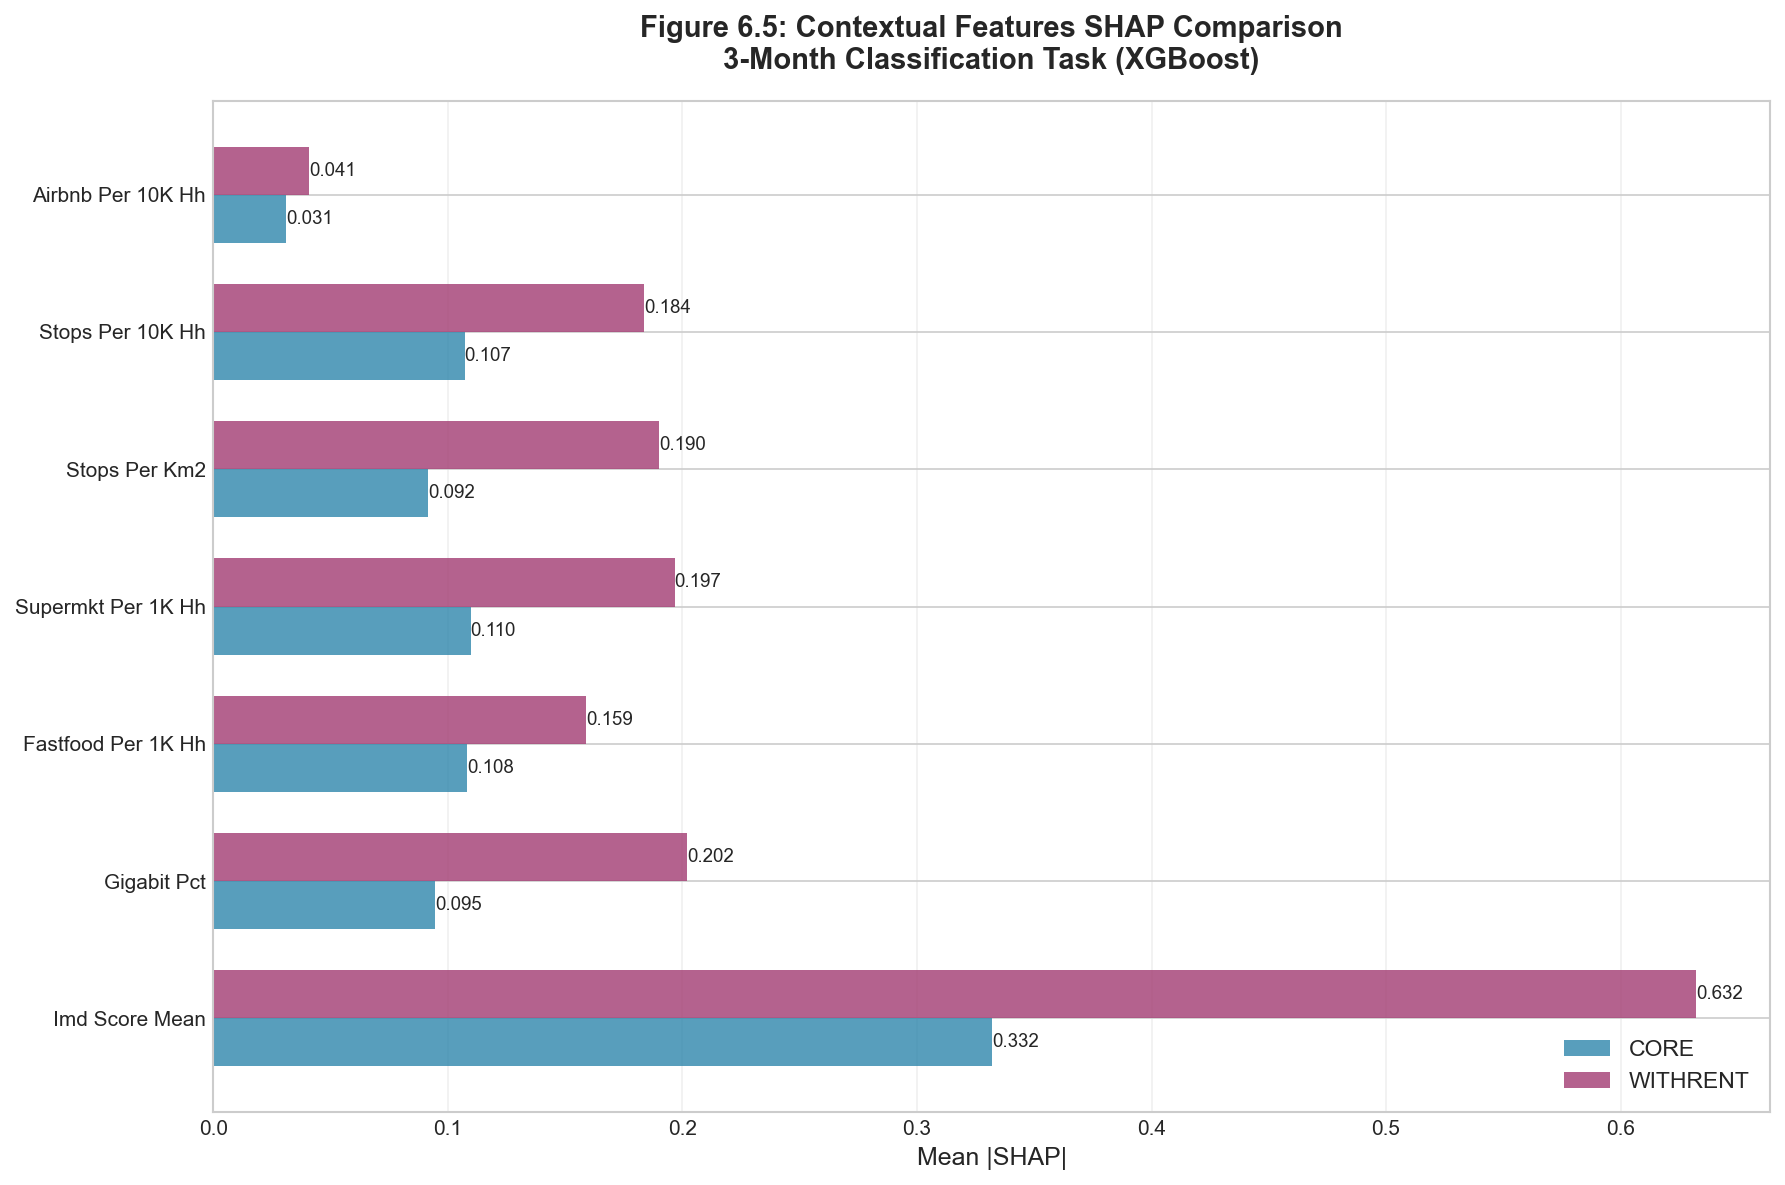


Summary:
           Feature     CORE  WITHRENT
    imd_score_mean 0.332138  0.632059
       gigabit_pct 0.094573  0.201875
fastfood_per_1k_hh 0.108178  0.158813
supermkt_per_1k_hh 0.109754  0.196724
     stops_per_km2 0.091654  0.190120
  stops_per_10k_hh 0.107104  0.183823
 airbnb_per_10k_hh 0.030956  0.040930


In [22]:
# Load SHAP files for both variants
shap_dir = TABLES_DIR

def load_shap_mean(variant, target='y_up_3m', task='cls'):
    """Load and aggregate SHAP values across folds."""
    pattern = f'shap_PROP_v1_{variant}_{task}_{target}_*.parquet'
    shap_files = list(shap_dir.glob(pattern))

    if not shap_files:
        return None

    all_shap = []
    for f in shap_files:
        df = pd.read_parquet(f)
        all_shap.append(df)

    combined = pd.concat(all_shap, ignore_index=True)
    return combined.groupby('feature')['abs_shap_mean'].mean()

# Load for both variants
core_shap = load_shap_mean('CORE')
withrent_shap = load_shap_mean('WITHRENT')

if core_shap is not None and withrent_shap is not None:
    # Define contextual features
    contextual_features = [
        'imd_score_mean',
        'gigabit_pct',
        'fastfood_per_1k_hh',
        'supermkt_per_1k_hh',
        'stops_per_km2',
        'stops_per_10k_hh',
        'airbnb_per_10k_hh'
    ]

    # Create comparison dataframe
    comparison_data = []
    for feat in contextual_features:
        if feat in core_shap.index and feat in withrent_shap.index:
            comparison_data.append({
                'Feature': feat,
                'CORE': core_shap[feat],
                'WITHRENT': withrent_shap[feat]
            })

    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)

        # Create figure
        fig, ax = plt.subplots(figsize=(12, 8))

        # Prepare data for plotting
        x = np.arange(len(comp_df))
        width = 0.35

        bars1 = ax.barh(x - width/2, comp_df['CORE'], width,
                       label='CORE', color='#2E86AB', alpha=0.8)
        bars2 = ax.barh(x + width/2, comp_df['WITHRENT'], width,
                       label='WITHRENT', color='#A23B72', alpha=0.8)

        # Format feature names for display
        feature_labels = [f.replace('_', ' ').title() for f in comp_df['Feature']]

        ax.set_yticks(x)
        ax.set_yticklabels(feature_labels)
        ax.set_xlabel('Mean |SHAP|', fontsize=12)
        ax.set_title('Figure 6.5: Contextual Features SHAP Comparison\n' +
                    '3-Month Classification Task (XGBoost)',
                    fontsize=14, fontweight='bold', pad=15)
        ax.legend(fontsize=11, loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')

        # Add value labels on bars
        for bars in [bars1, bars2]:
            for i, bar in enumerate(bars):
                width_bar = bar.get_width()
                ax.text(width_bar, bar.get_y() + bar.get_height()/2.,
                       f'{width_bar:.3f}',
                       ha='left', va='center', fontsize=9)

        plt.tight_layout()

        # Save figure
        fig_path = FIGS_DIR / 'fig_6_5_contextual_shap_core_vs_withrent.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_path}")
        plt.show()

        # Print summary
        print("\nSummary:")
        print(comp_df.to_string(index=False))
    else:
        print("No contextual features found in SHAP data.")
else:
    print("Could not load SHAP data for one or both variants.")


## Table 6.1: CORE Results Summary


In [25]:
# Load metrics
metrics_path = TABLES_DIR / 'metrics_PROP_v1_property.parquet'

if metrics_path.exists():
    metrics = pd.read_parquet(metrics_path)

    # Filter to CORE variant
    core_metrics = metrics[metrics['variant'] == 'CORE'].copy()

    if not core_metrics.empty:
        # Map model names
        core_metrics['model_name'] = core_metrics['model'].map({
            'logit': 'Linear/Logistic',
            'xgb': 'XGBoost'
        })

        # Map target names
        target_map = {
            'y_ret_1m_fwd': '1-Month Forward Returns',
            'y_ret_3m_fwd': '3-Month Forward Returns',
            'y_up_1m': '1-Month Up/Down',
            'y_up_3m': '3-Month Up/Down'
        }
        core_metrics['target_name'] = core_metrics['target'].map(target_map)

        # Map fold names
        fold_map = {
            'A_val2020': '2020',
            'B_val2022': '2022',
            'C_val2023': '2023'
        }
        core_metrics['fold_year'] = core_metrics['fold'].map(fold_map)

        # Create summary table
        # For regression and For classification

        summary_rows = []

        for target in ['y_ret_1m_fwd', 'y_ret_3m_fwd', 'y_up_1m', 'y_up_3m']:
            target_subset = core_metrics[core_metrics['target'] == target].copy()
            task = 'reg' if 'ret' in target else 'cls'

            for model in ['logit', 'xgb']:
                model_subset = target_subset[target_subset['model'] == model]

                if not model_subset.empty:
                    row = {
                        'Target': target_map[target],
                        'Model': 'Linear/Logistic' if model == 'logit' else 'XGBoost',
                        'Task': 'Regression' if task == 'reg' else 'Classification'
                    }

                    if task == 'reg':
                        row['RMSE'] = model_subset['rmse'].mean()
                        row['MAE'] = model_subset['mae'].mean()
                        row['R²'] = model_subset['r2'].mean()
                        row['Dir_Acc'] = model_subset['dir_acc'].mean()
                        row['Rank_IC'] = model_subset['rank_ic'].mean()
                    else:
                        row['AUC'] = model_subset['auc'].mean()
                        row['AP'] = model_subset['ap'].mean()
                        row['Acc'] = model_subset['acc'].mean()
                        row['F1'] = model_subset['f1'].mean()
                        row['Brier'] = model_subset['brier'].mean()
                        row['Rank_IC'] = model_subset['rank_ic'].mean()

                    # Add fold-specific metrics
                    for fold_year in ['2020', '2022', '2023']:
                        fold_subset = model_subset[model_subset['fold_year'] == fold_year]
                        if not fold_subset.empty:
                            if task == 'reg':
                                row[f'RMSE_{fold_year}'] = fold_subset['rmse'].iloc[0]
                                row[f'RankIC_{fold_year}'] = fold_subset['rank_ic'].iloc[0]
                            else:
                                row[f'AUC_{fold_year}'] = fold_subset['auc'].iloc[0]
                                row[f'RankIC_{fold_year}'] = fold_subset['rank_ic'].iloc[0]

                    summary_rows.append(row)

        summary_df = pd.DataFrame(summary_rows)

        # Round numeric columns
        numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
        summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

        # Display
        print("Table 6.1: CORE Results Summary\n")
        print(summary_df.to_string(index=False))

        # Save to CSV
        csv_path = TABLES_DIR / 'table_6_1_core_results.csv'
        summary_df.to_csv(csv_path, index=False)
        print(f"\nSaved: {csv_path}")

    else:
        print("No CORE variant data found.")
else:
    print(f"{metrics_path} not found. Skipping Table 6.1.")


Table 6.1: CORE Results Summary

                 Target           Model           Task   RMSE    MAE     R²  Dir_Acc  Rank_IC  RMSE_2020  RankIC_2020  RMSE_2022  RankIC_2022  RMSE_2023  RankIC_2023    AUC     AP    Acc     F1  Brier  AUC_2020  AUC_2022  AUC_2023
1-Month Forward Returns Linear/Logistic     Regression 0.0803 0.0611 0.1122   0.5966   0.3328     0.0783       0.3344     0.0787       0.3263     0.0838       0.3378    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
1-Month Forward Returns         XGBoost     Regression 0.0652 0.0473 0.1169   0.5659   0.3689     0.0654       0.3982     0.0643       0.3225     0.0660       0.3861    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
3-Month Forward Returns Linear/Logistic     Regression 0.0895 0.0703 0.0350   0.6206   0.3620     0.0835       0.4005     0.0877       0.3557     0.0972       0.3298    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
3-Month Forward Returns         XGBoost    

## Table 6.2: WITHRENT Results Summary


In [28]:
# Load metrics
metrics_path = TABLES_DIR / 'metrics_PROP_v1_property.parquet'

if metrics_path.exists():
    metrics = pd.read_parquet(metrics_path)

    # Filter to WITHRENT variant
    withrent_metrics = metrics[metrics['variant'] == 'WITHRENT'].copy()

    if not withrent_metrics.empty:
        # Map model names
        withrent_metrics['model_name'] = withrent_metrics['model'].map({
            'logit': 'Linear/Logistic',
            'xgb': 'XGBoost'
        })

        # Map target names
        target_map = {
            'y_ret_1m_fwd': '1-Month Forward Returns',
            'y_ret_3m_fwd': '3-Month Forward Returns',
            'y_up_1m': '1-Month Up/Down',
            'y_up_3m': '3-Month Up/Down'
        }
        withrent_metrics['target_name'] = withrent_metrics['target'].map(target_map)

        # Map fold names
        fold_map = {
            'A_val2020': '2020',
            'B_val2022': '2022',
            'C_val2023': '2023'
        }
        withrent_metrics['fold_year'] = withrent_metrics['fold'].map(fold_map)

        # Create summary table (same structure as Table 6.1)
        summary_rows = []

        for target in ['y_ret_1m_fwd', 'y_ret_3m_fwd', 'y_up_1m', 'y_up_3m']:
            target_subset = withrent_metrics[withrent_metrics['target'] == target].copy()
            task = 'reg' if 'ret' in target else 'cls'

            for model in ['logit', 'xgb']:
                model_subset = target_subset[target_subset['model'] == model]

                if not model_subset.empty:
                    row = {
                        'Target': target_map[target],
                        'Model': 'Linear/Logistic' if model == 'logit' else 'XGBoost',
                        'Task': 'Regression' if task == 'reg' else 'Classification'
                    }

                    if task == 'reg':
                        row['RMSE'] = model_subset['rmse'].mean()
                        row['MAE'] = model_subset['mae'].mean()
                        row['R²'] = model_subset['r2'].mean()
                        row['Dir_Acc'] = model_subset['dir_acc'].mean()
                        row['Rank_IC'] = model_subset['rank_ic'].mean()
                    else:
                        row['AUC'] = model_subset['auc'].mean()
                        row['AP'] = model_subset['ap'].mean()
                        row['Acc'] = model_subset['acc'].mean()
                        row['F1'] = model_subset['f1'].mean()
                        row['Brier'] = model_subset['brier'].mean()
                        row['Rank_IC'] = model_subset['rank_ic'].mean()

                    # Add fold-specific metrics
                    for fold_year in ['2020', '2022', '2023']:
                        fold_subset = model_subset[model_subset['fold_year'] == fold_year]
                        if not fold_subset.empty:
                            if task == 'reg':
                                row[f'RMSE_{fold_year}'] = fold_subset['rmse'].iloc[0]
                                row[f'RankIC_{fold_year}'] = fold_subset['rank_ic'].iloc[0]
                            else:
                                row[f'AUC_{fold_year}'] = fold_subset['auc'].iloc[0]
                                row[f'RankIC_{fold_year}'] = fold_subset['rank_ic'].iloc[0]

                    summary_rows.append(row)

        summary_df = pd.DataFrame(summary_rows)

        # Round numeric columns
        numeric_cols = summary_df.select_dtypes(include=[np.number]).columns
        summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

        # Display
        print("Table 6.2: WITHRENT Results Summary\n")
        print(summary_df.to_string(index=False))

        # Save to CSV
        csv_path = TABLES_DIR / 'table_6_2_withrent_results.csv'
        summary_df.to_csv(csv_path, index=False)
        print(f"\nSaved: {csv_path}")

    else:
        print("No WITHRENT variant data found.")
else:
    print(f"{metrics_path} not found. Skipping Table 6.2.")


Table 6.2: WITHRENT Results Summary

                 Target           Model           Task   RMSE    MAE      R²  Dir_Acc  Rank_IC  RMSE_2020  RankIC_2020  RMSE_2022  RankIC_2022  RMSE_2023  RankIC_2023    AUC     AP    Acc     F1  Brier  AUC_2020  AUC_2022  AUC_2023
1-Month Forward Returns Linear/Logistic     Regression 0.0820 0.0628  0.0745   0.5713   0.3320     0.0788       0.3370     0.0787       0.3240     0.0885       0.3350    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
1-Month Forward Returns         XGBoost     Regression 0.0699 0.0526 -0.0183   0.5557   0.3910     0.0681       0.4241     0.0742       0.3528     0.0672       0.3961    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
3-Month Forward Returns Linear/Logistic     Regression 0.0857 0.0665  0.1197   0.6143   0.3577     0.0830       0.3998     0.0892       0.3465     0.0849       0.3268    NaN    NaN    NaN    NaN    NaN       NaN       NaN       NaN
3-Month Forward Returns         XGB